In [1]:
import duckdb

# connect to your database
con = duckdb.connect('../data/warehouse_new.duckdb')  # adjust path if needed


In [2]:
con.execute("SHOW TABLES").fetchdf()


,name
0,customer_list_xls
1,customer_list_xlsx
2,electricity_sales_all
3,merged_sales_customers
4,sales_2012_2017
5,sales_2018_2019


In [3]:
import pandas as pd

sales_2012_2017 = con.execute("""
    SELECT * FROM sales_2012_2017
""").fetchdf()

sales_2018_2019 = con.execute("""
    SELECT * FROM sales_2018_2019
""").fetchdf()


In [4]:
sales_2012_2017.head()

,meterid,od_date,ordersid,ocd_energy,ocd_taxes,ocd_paymoney,payforarrears,ocd_servicecharge,ocd_leviescharge,ocd_cash_received,ocd_subsidy,ocd_nel_charge,ocd_slv_charge,ocd_vat1_charge,ocd_vat2_charge,ocd_month_consumption,ocd_energy_cost,source_sheet
0,1010451111,2013-08-27 09:56:04,413082700130806,30.40,0.0,20.0,0.0,14.8788,0.0111,20.0,1.3340,0.0086,0.0025,0.0,0.0,0.0,5.1101,2012-13
1,1010451111,2013-08-27 12:13:34,413082700130996,61.65,0.0,10.0,0.0,0.0000,0.0136,10.0,3.3059,0.0105,0.0031,0.0,0.0,30.4,9.9864,2012-13
2,10010284581,2012-10-25 18:23:42,412102500004294,30.14,0.0,6.0,0.0,1.6532,0.0110,6.0,0.9920,0.0085,0.0025,0.0,0.0,0.0,4.3358,2012-13
3,10102444391,2013-12-12 14:04:52,413121200213008,32.08,0.0,15.0,0.0,2.5675,0.0115,15.0,3.9578,0.0089,0.0026,0.0,0.0,0.0,12.4210,2012-13
4,11010003761,2013-02-15 11:28:55,413021500035162,64.54,0.0,12.0,0.0,3.3064,0.0142,12.0,2.6654,0.0110,0.0032,0.0,0.0,0.0,8.6794,2012-13


In [5]:
sales_2018_2019.head()

,meterid,od_date,ordersid,ocd_energy,ocd_taxes,ocd_paymoney,payforarrears,ocd_servicecharge,ocd_leviescharge,ocd_cash_received,ocd_subsidy,ocd_nel_charge,ocd_slv_charge,ocd_vat1_charge,ocd_vat2_charge,ocd_month_consumption,ocd_energy_cost,source_sheet
0,11010003761,2018-01-27 17:01:48,418012702482884,59.9,0.0,40.0,0.0,0.0000,2.0165,40.0,2.3301,0.8066,1.2099,0.0,0.0,200.5,38.0006,01-03-2018
1,11010003761,2018-03-29 21:10:22,418032902651069,51.3,0.0,25.0,0.0,0.0000,1.4246,25.0,0.0000,0.5698,0.8548,0.0,0.0,200.5,28.4920,01-03-2018
2,11010003761,2018-03-01 19:09:22,418030102577352,200.5,0.0,123.0,0.0,6.3317,5.9056,123.0,12.2945,2.3622,3.5433,0.0,0.0,0.0,105.8172,01-03-2018
3,11010003761,2018-01-02 17:56:48,418010202428153,200.5,0.0,123.0,0.0,6.3317,5.9056,123.0,12.2945,2.3622,3.5433,0.0,0.0,0.0,105.8172,01-03-2018
4,11010003761,2018-02-05 17:47:33,418020502514379,200.5,0.0,123.0,0.0,6.3317,5.9056,123.0,12.2945,2.3622,3.5433,0.0,0.0,0.0,105.8172,01-03-2018


# The columns of both the tables are identical

In [6]:
# Assuming you already have:
# sales_2012_2017 and sales_2018_2019 as DataFrames

cols_12_17 = list(sales_2012_2017.columns)
cols_18_19 = list(sales_2018_2019.columns)

# 1. Check if columns match exactly (same names + same order)
cols_12_17 == cols_18_19


True

In [7]:
import pandas as pd

# --- 1) Pick the date column automatically (override DATE_COL if needed) ---
def find_date_col(df):
    preferred = {'date','bill_date','reading_date','timestamp','period','period_start'}
    for c in df.columns:
        if str(c).lower() in preferred:
            return c
    for c in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[c]):
            return c
    for c in df.columns:
        try:
            pd.to_datetime(df[c].head(30), errors='raise', infer_datetime_format=True)
            return c
        except Exception:
            pass
    return None

DATE_COL = find_date_col(sales_2012_2017) or find_date_col(sales_2018_2019)
assert DATE_COL is not None, "Set DATE_COL manually, e.g. DATE_COL = 'bill_date'"

# ensure datetime
for df in (sales_2012_2017, sales_2018_2019):
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')

# --- 2) Ranges ---
span_1217 = (sales_2012_2017[DATE_COL].min(), sales_2012_2017[DATE_COL].max())
span_1819 = (sales_2018_2019[DATE_COL].min(), sales_2018_2019[DATE_COL].max())
print("2012–2017 range:", span_1217)
print("2018–2019 range:", span_1819)

# --- 3) Overlap / gap ---
start_overlap = max(span_1217[0], span_1819[0])
end_overlap   = min(span_1217[1], span_1819[1])
overlap = start_overlap <= end_overlap
print("Do ranges overlap?:", overlap)
if not overlap:
    # positive days means a gap
    gap_days = (min(span_1217[0], span_1819[0]) - max(span_1217[1], span_1819[1])).days
    print("Gap (days):", abs(gap_days))

# --- 4) How many distinct dates overlap? ---
dates1 = pd.to_datetime(sales_2012_2017[DATE_COL]).dt.normalize().unique()
dates2 = pd.to_datetime(sales_2018_2019[DATE_COL]).dt.normalize().unique()
overlap_dates = pd.Index(dates1).intersection(dates2)
print("Overlapping distinct dates:", len(overlap_dates))

# --- 5) Optional: row-level conflicts for same KEY + DATE (set your keys) ---
# If you have an identifier like 'customer_id' or 'account_id', set KEY_COLS:
KEY_COLS = None  # e.g., ['customer_id'] or ['account_id','meter_id']
if KEY_COLS:
    a = sales_2012_2017[KEY_COLS + [DATE_COL]].dropna()
    b = sales_2018_2019[KEY_COLS + [DATE_COL]].dropna()
    dup_keys = (pd.concat([a, b]).duplicated(keep=False))
    print("Rows with same KEY(s)+DATE across tables:", dup_keys.sum())


2012–2017 range: (Timestamp('2012-07-17 19:15:03'), Timestamp('2017-12-30 21:39:28'))
2018–2019 range: (Timestamp('2018-01-01 06:48:49'), Timestamp('2020-09-15 21:15:25'))
Do ranges overlap?: False
Gap (days): 2983
Overlapping distinct dates: 0


In [10]:
sales_2012_2017['od_date'][100000]

Timestamp('2013-10-17 14:50:50')

# Merge both tables to electricty_all

In [11]:
# merge
con.execute("""
CREATE OR REPLACE TABLE electricity_sales_all AS
SELECT *, '2012_2017' AS vintage FROM sales_2012_2017
UNION ALL
SELECT *, '2018_2019' AS vintage FROM sales_2018_2019;
""")

# confirm
con.sql("""
SELECT vintage, MIN(od_date) AS min_date, MAX(od_date) AS max_date, COUNT(*) AS rows
FROM electricity_sales_all
GROUP BY vintage;
""").show()

┌───────────┬─────────────────────┬─────────────────────┬─────────┐
│  vintage  │      min_date       │      max_date       │  rows   │
│  varchar  │    timestamp_ns     │    timestamp_ns     │  int64  │
├───────────┼─────────────────────┼─────────────────────┼─────────┤
│ 2012_2017 │ 2012-07-17 19:15:03 │ 2017-12-30 21:39:28 │ 2396617 │
│ 2018_2019 │ 2018-01-01 06:48:49 │ 2020-09-15 21:15:25 │ 3269399 │
└───────────┴─────────────────────┴─────────────────────┴─────────┘



In [12]:
df = con.sql("SELECT * FROM electricity_sales_all").fetchdf()
df.head()


,meterid,od_date,ordersid,ocd_energy,ocd_taxes,ocd_paymoney,payforarrears,ocd_servicecharge,ocd_leviescharge,ocd_cash_received,ocd_subsidy,ocd_nel_charge,ocd_slv_charge,ocd_vat1_charge,ocd_vat2_charge,ocd_month_consumption,ocd_energy_cost,source_sheet,vintage
0,1010451111,2013-08-27 09:56:04,413082700130806,30.40,0.0,20.0,0.0,14.8788,0.0111,20.0,1.3340,0.0086,0.0025,0.0,0.0,0.0,5.1101,2012-13,2012_2017
1,1010451111,2013-08-27 12:13:34,413082700130996,61.65,0.0,10.0,0.0,0.0000,0.0136,10.0,3.3059,0.0105,0.0031,0.0,0.0,30.4,9.9864,2012-13,2012_2017
2,10010284581,2012-10-25 18:23:42,412102500004294,30.14,0.0,6.0,0.0,1.6532,0.0110,6.0,0.9920,0.0085,0.0025,0.0,0.0,0.0,4.3358,2012-13,2012_2017
3,10102444391,2013-12-12 14:04:52,413121200213008,32.08,0.0,15.0,0.0,2.5675,0.0115,15.0,3.9578,0.0089,0.0026,0.0,0.0,0.0,12.4210,2012-13,2012_2017
4,11010003761,2013-02-15 11:28:55,413021500035162,64.54,0.0,12.0,0.0,3.3064,0.0142,12.0,2.6654,0.0110,0.0032,0.0,0.0,0.0,8.6794,2012-13,2012_2017


In [14]:
customer_list = con.sql("SELECT * FROM customer_list_xls").fetchdf()
customer_list.head()

,volta river authority northern electricity department,unnamed: 1,unnamed: 2,unnamed: 3,unnamed: 4,unnamed: 5,unnamed: 6,unnamed: 7,unnamed: 8,unnamed: 9,unnamed: 10,unnamed: 11,unnamed: 12,unnamed: 13,unnamed: 14,unnamed: 15,source_sheet
0,Customer No.,Meter No.,Customer Name,Customer Address,Paid Mode.,Utility,Account Status,Account Open Date,Tariff Type,CBMS Customer No.,PPM Customer No.,Contact Person,Contact Number,Identification Number,Power Supply State,Block State,Techiman
1,501002891101,18057591261,MEG OSADOLOR,STORE@PLOT NO. 86 BLK L SECT 6S BAMIRI,Prepaid,Techiman,Active,20/01/2022,Non Residential,SQ1206960,None,MEG OSADOLOR,0560862224,None,Connected,0,Techiman
2,501002869623,017015603711,SEIBA ABINDAU,PLOT NO. 8 TUOBODOM,Prepaid,Techiman,Active,07/10/2021,Residential,SQ1203958,None,SEIDU ABINDAU,0552794548,None,Connected,0,Techiman
3,501002873318,017015801331,OPOKU BOAMAH CLEMENT,BOREHOLE@PLOT NO. 12A BLK A SECT BAMIRI,Prepaid,Techiman,Active,22/10/2021,Non Residential,SQ1205049,None,OPOKU BOAMAH CLEMENT,0596384100,None,Connected,0,Techiman
4,501002856027,20193368717,SOMUAH JOSEPH,"PLOT NO. 192 BLK B, SECT 11, ASIKO TOWN, JAMA",Prepaid,Techiman,Active,12/08/2021,Residential,SQ1202508,None,SOMUAH JOSEPH,0245726636,None,Connected,0,Techiman


In [15]:
# promote the proper header row
hdr = customer_list.index[
    customer_list.apply(lambda r: r.astype(str).str.contains("Customer No", case=False, na=False)).any(axis=1)
][0]

customer_list.columns = customer_list.iloc[hdr].astype(str)
customer_list = customer_list.iloc[hdr + 1:].reset_index(drop=True)

# drop "unnamed" junk columns and normalize headers
customer_list = customer_list.loc[:, ~customer_list.columns.str.contains("unnamed", case=False)]
customer_list.columns = (
    customer_list.columns.str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

# optional: parse date column
if "account_open_date" in customer_list.columns:
    customer_list["account_open_date"] = pd.to_datetime(
        customer_list["account_open_date"], errors="coerce", dayfirst=True
    )

customer_list.head()


,customer_no.,meter_no.,customer_name,customer_address,paid_mode.,utility,account_status,account_open_date,tariff_type,cbms_customer_no.,ppm_customer_no.,contact_person,contact_number,identification_number,power_supply_state,block_state,techiman
0,501002891101,18057591261,MEG OSADOLOR,STORE@PLOT NO. 86 BLK L SECT 6S BAMIRI,Prepaid,Techiman,Active,2022-01-20,Non Residential,SQ1206960,None,MEG OSADOLOR,0560862224,None,Connected,0,Techiman
1,501002869623,017015603711,SEIBA ABINDAU,PLOT NO. 8 TUOBODOM,Prepaid,Techiman,Active,2021-10-07,Residential,SQ1203958,None,SEIDU ABINDAU,0552794548,None,Connected,0,Techiman
2,501002873318,017015801331,OPOKU BOAMAH CLEMENT,BOREHOLE@PLOT NO. 12A BLK A SECT BAMIRI,Prepaid,Techiman,Active,2021-10-22,Non Residential,SQ1205049,None,OPOKU BOAMAH CLEMENT,0596384100,None,Connected,0,Techiman
3,501002856027,20193368717,SOMUAH JOSEPH,"PLOT NO. 192 BLK B, SECT 11, ASIKO TOWN, JAMA",Prepaid,Techiman,Active,2021-08-12,Residential,SQ1202508,None,SOMUAH JOSEPH,0245726636,None,Connected,0,Techiman
4,501002865664,20195170715,SERWAA JAMILA,"PLOT NO. 152 BLK. A SECT. 6, TAKYIKROM",Prepaid,Techiman,Active,2021-09-15,Residential,None,None,SERWAA JAMILA,0548406768,None,Connected,0,Techiman


In [20]:
customer_list.columns

Index(['customer_no.', 'meter_no.', 'customer_name', 'customer_address',
       'paid_mode.', 'utility', 'account_status', 'account_open_date',
       'tariff_type', 'cbms_customer_no.', 'ppm_customer_no.',
       'contact_person', 'contact_number', 'identification_number',
       'power_supply_state', 'block_state', 'techiman'],
      dtype='object', name=0)

In [21]:
customer_list = customer_list.drop(columns=["techiman"])
customer_list

,customer_no.,meter_no.,customer_name,customer_address,paid_mode.,utility,account_status,account_open_date,tariff_type,cbms_customer_no.,ppm_customer_no.,contact_person,contact_number,identification_number,power_supply_state,block_state
0,501002891101,18057591261,MEG OSADOLOR,STORE@PLOT NO. 86 BLK L SECT 6S BAMIRI,Prepaid,Techiman,Active,2022-01-20,Non Residential,SQ1206960,None,MEG OSADOLOR,0560862224,None,Connected,0
1,501002869623,017015603711,SEIBA ABINDAU,PLOT NO. 8 TUOBODOM,Prepaid,Techiman,Active,2021-10-07,Residential,SQ1203958,None,SEIDU ABINDAU,0552794548,None,Connected,0
2,501002873318,017015801331,OPOKU BOAMAH CLEMENT,BOREHOLE@PLOT NO. 12A BLK A SECT BAMIRI,Prepaid,Techiman,Active,2021-10-22,Non Residential,SQ1205049,None,OPOKU BOAMAH CLEMENT,0596384100,None,Connected,0
3,501002856027,20193368717,SOMUAH JOSEPH,"PLOT NO. 192 BLK B, SECT 11, ASIKO TOWN, JAMA",Prepaid,Techiman,Active,2021-08-12,Residential,SQ1202508,None,SOMUAH JOSEPH,0245726636,None,Connected,0
4,501002865664,20195170715,SERWAA JAMILA,"PLOT NO. 152 BLK. A SECT. 6, TAKYIKROM",Prepaid,Techiman,Active,2021-09-15,Residential,None,None,SERWAA JAMILA,0548406768,None,Connected,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109637,515002020181,020189875618,SOPHIA DANSOWAH,DNT-78 DUMASUA,Prepaid,Abofour,Active,2019-03-13,Residential,504001769,None,None,None,None,Connected,0
109638,515002020846,020190186310,YAA KONADU,H/NO. NR DNT- 82 ABOFOUR,Prepaid,Abofour,Active,2019-03-13,Residential,504018551,None,None,None,None,Connected,0
109639,515002020293,20191825114,THE PASTOR,S.D.A. CHURCH ABOFOUR,Prepaid,Abofour,Active,2019-03-13,Non Residential,504004060,None,None,None,None,Connected,0
109640,515002020359,020190861417,KWABENA DWAMENA,PLOT NO. 96 ABOFOUR,Prepaid,Abofour,Active,2019-03-13,Non Residential,504006018,None,None,None,None,Connected,0


In [22]:
# align column names
sales = con.sql("SELECT * FROM electricity_sales_all").fetchdf()

# find the meter ID columns
sales.columns, customer_list.columns


(Index(['meterid', 'od_date', 'ordersid', 'ocd_energy', 'ocd_taxes',
        'ocd_paymoney', 'payforarrears', 'ocd_servicecharge',
        'ocd_leviescharge', 'ocd_cash_received', 'ocd_subsidy',
        'ocd_nel_charge', 'ocd_slv_charge', 'ocd_vat1_charge',
        'ocd_vat2_charge', 'ocd_month_consumption', 'ocd_energy_cost',
        'source_sheet', 'vintage'],
       dtype='object'),
 Index(['customer_no.', 'meter_no.', 'customer_name', 'customer_address',
        'paid_mode.', 'utility', 'account_status', 'account_open_date',
        'tariff_type', 'cbms_customer_no.', 'ppm_customer_no.',
        'contact_person', 'contact_number', 'identification_number',
        'power_supply_state', 'block_state'],
       dtype='object', name=0))

In [23]:
sales_meter = set(sales['meterid'].astype(str).str.strip())
cust_meter  = set(customer_list['meter_no.'].astype(str).str.strip())

# how many overlap
len(sales_meter & cust_meter), len(sales_meter), len(cust_meter)


(0, 76941, 107143)

In [25]:
sales['meterid'].head(10)

0     1010451111
1     1010451111
2    10010284581
3    10102444391
4    11010003761
5    11010003761
6    11010003761
7    11010003761
8    11010003761
9    11010003761
Name: meterid, dtype: object

In [26]:
customer_list['meter_no.'].head(10)

0     18057591261
1    017015603711
2    017015801331
3     20193368717
4     20195170715
5     20194117717
6     20196264228
7     20194936215
8    014012468521
9    017015694471
Name: meter_no., dtype: object

In [27]:
sales_meter_padded = {"0" + x if len(x) == 10 else x for x in sales['meterid'].astype(str)}
cust_meter = set(customer_list['meter_no.'].astype(str).str.strip())

len(sales_meter_padded & cust_meter)


0

In [28]:
import re
digits = lambda s: re.sub(r'\D', '', str(s))

# 1) Inspect length patterns
sales_len = sales['meterid'].astype(str).map(digits).str.len().value_counts().sort_index()
cust_len  = customer_list['meter_no.'].astype(str).map(digits).str.len().value_counts().sort_index()
sales_len, cust_len


(meterid
 10         13
 11    5665965
 12         38
 Name: count, dtype: int64,
 meter_no.
 0      2501
 5         1
 6        11
 9         5
 10        1
 11    20117
 12    86987
 13       14
 14        2
 23        1
 24        2
 Name: count, dtype: int64)

In [29]:
import re
digits = lambda s: re.sub(r'\D', '', str(s))

# 1) normalize: keep digits only, drop leading zeros
sales_norm = sales['meterid'].astype(str).map(digits).str.lstrip('0')
cust_norm  = customer_list['meter_no.'].astype(str).map(digits).str.lstrip('0')

# drop empties
sales_norm = sales_norm[sales_norm.ne('')]
cust_norm  = cust_norm[cust_norm.ne('')]

S = set(sales_norm)
C = set(cust_norm)

len_match = len(S & C), len(S), len(C)
len_match


(71054, 76941, 107138)

In [33]:
import re

def norm_digits(s):
    return (s.astype(str)
             .str.replace(r'\D', '', regex=True)  # keep digits only
             .str.lstrip('0'))                    # drop leading zeros

# 1) normalize columns (same length as originals)
sales['meterid_norm']      = norm_digits(sales['meterid'])
customer_list['meter_no_norm'] = norm_digits(customer_list['meter_no.'])

# 2) inner join on normalized IDs
merged = sales.merge(
    customer_list,
    left_on='meterid_norm',
    right_on='meter_no_norm',
    how='inner',
    suffixes=('_sales', '_cust')
)

len(merged), merged.head()


(5255324,
        meterid             od_date         ordersid  ocd_energy  ocd_taxes  \
 0  10010284581 2012-10-25 18:23:42  412102500004294       30.14        0.0   
 1  11010003761 2013-02-15 11:28:55  413021500035162       64.54        0.0   
 2  11010003761 2013-06-01 17:43:41  413060100085898      146.19        0.0   
 3  11010003761 2013-09-30 12:23:37  413093000151311      147.60        0.0   
 4  11010003761 2013-07-27 18:33:55  413072700114544      156.48        0.0   
 
    ocd_paymoney  payforarrears  ocd_servicecharge  ocd_leviescharge  \
 0          6.00           0.00             1.6532            0.0110   
 1         12.00           0.00             3.3064            0.0142   
 2         23.00           0.00             3.3064            0.0322   
 3         23.19         121.81             3.3064            0.0325   
 4         23.00           0.00             1.6532            0.0344   
 
    ocd_cash_received  ...  account_open_date  tariff_type  cbms_customer_no.  \

In [35]:
# matched ones
matched_ids = set(merged["meterid_norm"])

# sales without customer match
unmatched_sales = sales[~sales["meterid_norm"].isin(matched_ids)]

# customers without sales match
unmatched_customers = customer_list[~customer_list["meter_no_norm"].isin(matched_ids)]

len(unmatched_sales), len(unmatched_customers)


(410863, 38585)

In [36]:
import pandas as pd
import re

# helpers
digits = lambda s: re.sub(r"\D", "", str(s))

# unmatched subsets (already computed)
unmatched_sales["meterid_digits"] = unmatched_sales["meterid_norm"].astype(str).map(digits)
unmatched_customers["meter_no_digits"] = unmatched_customers["meter_no_norm"].astype(str).map(digits)

# 1. Length distribution
sales_len = unmatched_sales["meterid_digits"].str.len().value_counts().sort_index()
cust_len  = unmatched_customers["meter_no_digits"].str.len().value_counts().sort_index()
print("Sales unmatched ID lengths:\n", sales_len)
print("\nCustomer unmatched ID lengths:\n", cust_len)

# 2. Sample differences
print("\nSample unmatched sales IDs:")
print(unmatched_sales["meterid_digits"].drop_duplicates().head(20).tolist())

print("\nSample unmatched customer IDs:")
print(unmatched_customers["meter_no_digits"].drop_duplicates().head(20).tolist())

# 3. Prefix / suffix check
unmatched_sales["prefix2"] = unmatched_sales["meterid_digits"].str[:2]
unmatched_customers["prefix2"] = unmatched_customers["meter_no_digits"].str[:2]
print("\nTop sales prefixes:\n", unmatched_sales["prefix2"].value_counts().head(10))
print("\nTop customer prefixes:\n", unmatched_customers["prefix2"].value_counts().head(10))


C:\Users\Asus\AppData\Local\Temp\ipykernel_6012\4153450667.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unmatched_sales["meterid_digits"] = unmatched_sales["meterid_norm"].astype(str).map(digits)
C:\Users\Asus\AppData\Local\Temp\ipykernel_6012\4153450667.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unmatched_customers["meter_no_digits"] = unmatched_customers["meter_no_norm"].astype(str).map(digits)


Sales unmatched ID lengths:
 meterid_digits
10        12
11    410813
12        38
Name: count, dtype: int64

Customer unmatched ID lengths:
 meter_no_digits
0      2501
3         2
4         2
5        14
6        15
8       251
9         6
10       38
11    35745
12        7
13        1
22        1
23        2
Name: count, dtype: int64

Sample unmatched sales IDs:
['1010451111', '10102444391', '11010003781', '11010003791', '11010005231', '11010005541', '11010005791', '11010005951', '11010006201', '11010006231', '11010006331', '11010006611', '11010006691', '11010006701', '11010006881', '11010007121', '11010018231', '11010018361', '11010018411', '11010018431']

Sample unmatched customer IDs:
['18057591261', '20193368717', '20195170715', '20194117717', '20196264228', '20194936215', '20192883815', '20192858916', '20192885216', '20192899712', '20196264723', '', '20196275521', '20194583512', '18057545971', '18057637031', '18057567121', '18057417181', '18057614871', '18057599241']

Top sale

C:\Users\Asus\AppData\Local\Temp\ipykernel_6012\4153450667.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unmatched_sales["prefix2"] = unmatched_sales["meterid_digits"].str[:2]
C:\Users\Asus\AppData\Local\Temp\ipykernel_6012\4153450667.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unmatched_customers["prefix2"] = unmatched_customers["meter_no_digits"].str[:2]


In [37]:
import re, numpy as np
digits = lambda s: re.sub(r'\D','', str(s))

# normalize both sides
sales['meterid_norm'] = sales['meterid'].astype(str).map(digits).str.lstrip('0')

cust_digits = customer_list['meter_no.'].astype(str).map(digits)
customer_list['meter_no_norm'] = np.where(
    cust_digits.str.len() >= 12,      # prefixed form
    cust_digits.str[2:],              # drop first 2 digits
    cust_digits                       # keep as-is
)

# merge
merged = sales.merge(
    customer_list,
    left_on='meterid_norm',
    right_on='meter_no_norm',
    how='inner',
    suffixes=('_sales','_cust')
)

# leftovers (optional)
matched = set(merged['meterid_norm'])
unmatched_sales = sales[~sales['meterid_norm'].isin(matched)]
unmatched_customers = customer_list[~customer_list['meter_no_norm'].isin(matched)]

len(merged), len(unmatched_sales), len(unmatched_customers)


(272, 5665744, 109634)

In [38]:
import re
def norm(s):
    return (s.astype(str)
              .str.replace(r'\D','', regex=True)  # keep digits
              .str.lstrip('0'))                   # drop leading zeros

# normalize
sales['meterid_norm']        = norm(sales['meterid'])
customer_list['meter_no_norm'] = norm(customer_list['meter_no.'])

# sanity: unique-ID overlap
len(set(sales['meterid_norm']) & set(customer_list['meter_no_norm']))


71054

In [39]:
cust_keyed = customer_list.drop_duplicates('meter_no_norm')
merged = sales.merge(
    cust_keyed,
    left_on='meterid_norm',
    right_on='meter_no_norm',
    how='inner',
    suffixes=('_sales','_cust')
)
len(merged)


5255153

In [40]:
sales['meterid_last11'] = sales['meterid_norm'].str[-11:]
customer_list['meter_no_last11'] = customer_list['meter_no_norm'].str[-11:]

alt_overlap = len(set(sales['meterid_last11']) & set(customer_list['meter_no_last11']))
alt_overlap
# If alt_overlap >> previous, merge on the *_last11 columns instead.


71055

In [41]:
matched = set(merged['meterid_norm'])
unmatched_sales      = sales[~sales['meterid_norm'].isin(matched)]
unmatched_customers  = customer_list[~customer_list['meter_no_norm'].isin(matched)]

# blanks / bad lengths drive most misses
unmatched_customers['meter_no_norm'].str.len().value_counts().sort_index()
unmatched_customers['meter_no_norm'].eq('').sum()


np.int64(2501)

In [42]:
import re
digits = lambda s: re.sub(r'\D','', str(s))

# Normalize both
sales['meterid_norm'] = sales['meterid'].astype(str).map(digits).str[-11:]
customer_list['meter_no_norm'] = customer_list['meter_no.'].astype(str).map(digits).str[-11:]

# Merge
merged = sales.merge(
    customer_list,
    left_on='meterid_norm',
    right_on='meter_no_norm',
    how='inner',
    suffixes=('_sales','_cust')
)

print("matches:", len(merged))


matches: 5255472


In [44]:
merged.columns

Index(['meterid', 'od_date', 'ordersid', 'ocd_energy', 'ocd_taxes',
       'ocd_paymoney', 'payforarrears', 'ocd_servicecharge',
       'ocd_leviescharge', 'ocd_cash_received', 'ocd_subsidy',
       'ocd_nel_charge', 'ocd_slv_charge', 'ocd_vat1_charge',
       'ocd_vat2_charge', 'ocd_month_consumption', 'ocd_energy_cost',
       'source_sheet', 'vintage', 'meterid_norm', 'meterid_last11',
       'customer_no.', 'meter_no.', 'customer_name', 'customer_address',
       'paid_mode.', 'utility', 'account_status', 'account_open_date',
       'tariff_type', 'cbms_customer_no.', 'ppm_customer_no.',
       'contact_person', 'contact_number', 'identification_number',
       'power_supply_state', 'block_state', 'meter_no_norm',
       'meter_no_last11'],
      dtype='object')

Date range: 2012-07-17 19:15:03 → 2020-09-15 21:15:25
Missing 2983 days
First 10 missing days:
DatetimeIndex(['2012-07-17 19:15:03', '2012-07-18 19:15:03',
               '2012-07-19 19:15:03', '2012-07-20 19:15:03',
               '2012-07-21 19:15:03', '2012-07-22 19:15:03',
               '2012-07-23 19:15:03', '2012-07-24 19:15:03',
               '2012-07-25 19:15:03', '2012-07-26 19:15:03'],
              dtype='datetime64[ns]', freq='D')


<Axes: title={'center': 'Records per Month'}, xlabel='year_month'>

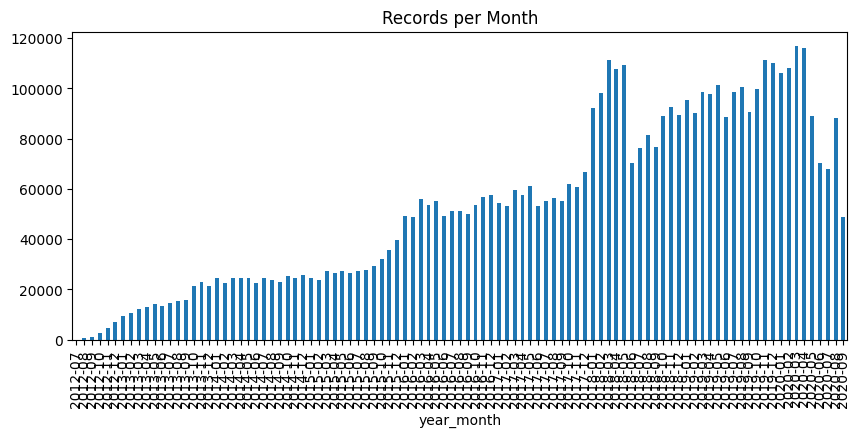

In [47]:
import pandas as pd

# make sure od_date is a datetime column
merged['od_date'] = pd.to_datetime(merged['od_date'], errors='coerce')

# 1) overall date range
print("Date range:", merged['od_date'].min(), "→", merged['od_date'].max())

# 2) find missing calendar days
all_days = pd.date_range(merged['od_date'].min(), merged['od_date'].max())
existing_days = merged['od_date'].dt.floor('D').dropna().unique()
missing_days = all_days.difference(existing_days)

print(f"Missing {len(missing_days)} days")
if len(missing_days) > 0:
    print("First 10 missing days:")
    print(missing_days[:10])

# 3) optional: check monthly record density
merged['year_month'] = merged['od_date'].dt.to_period('M')
monthly_counts = merged['year_month'].value_counts().sort_index()
monthly_counts.plot(kind='bar', figsize=(10,4), title='Records per Month')


In [48]:
merged['date_only'] = merged['od_date'].dt.date
all_days = pd.date_range(min(merged['date_only']), max(merged['date_only']))
existing_days = pd.Series(merged['date_only']).unique()
missing_days = all_days.difference(existing_days)

print(f"Total days in range: {len(all_days)}")
print(f"Actual missing days: {len(missing_days)}")


Total days in range: 2983
Actual missing days: 38


In [4]:
merged_clean = merged.drop(columns=['year_month'], errors='ignore')

con.register("merged_df", merged_clean)
con.execute("CREATE OR REPLACE TABLE merged_sales_customers AS SELECT * FROM merged_df")
con.unregister("merged_df")

print("Table saved as merged_sales_customers")


NameError: name 'merged' is not defined

In [3]:
data = con.sql("SELECT * FROM merged_sales_customers").fetchdf()
data

,meterid,od_date,ordersid,ocd_energy,ocd_taxes,ocd_paymoney,payforarrears,ocd_servicecharge,ocd_leviescharge,ocd_cash_received,...,cbms_customer_no.,ppm_customer_no.,contact_person,contact_number,identification_number,power_supply_state,block_state,meter_no_norm,meter_no_last11,date_only
0,10010284581,2012-10-25 18:23:42,412102500004294,30.14,0.00,6.00,0.00,1.6532,0.0110,6.0,...,501107810,4000000000002112,None,None, ,Connected,0,10010284581,10010284581,2012-10-25
1,11010003761,2013-02-15 11:28:55,413021500035162,64.54,0.00,12.00,0.00,3.3064,0.0142,12.0,...,501174500,4000000000006517,None,None, ,Connected,0,11010003761,11010003761,2013-02-15
2,11010003761,2013-06-01 17:43:41,413060100085898,146.19,0.00,23.00,0.00,3.3064,0.0322,23.0,...,501174500,4000000000006517,None,None, ,Connected,0,11010003761,11010003761,2013-06-01
3,11010003761,2013-09-30 12:23:37,413093000151311,147.60,0.00,23.19,121.81,3.3064,0.0325,145.0,...,501174500,4000000000006517,None,None, ,Connected,0,11010003761,11010003761,2013-09-30
4,11010003761,2013-07-27 18:33:55,413072700114544,156.48,0.00,23.00,0.00,1.6532,0.0344,23.0,...,501174500,4000000000006517,None,None, ,Connected,0,11010003761,11010003761,2013-07-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5255467,19018242161,2020-07-03 12:18:57,420070305376373,31.10,6.52,45.00,-25.00,12.4282,1.2407,20.0,...,513171201,4000000000075638,None,None, ,Connected,0,19018242161,19018242161,2020-07-03
5255468,19018242161,2020-09-11 15:06:07,420091105566298,30.70,4.29,30.00,0.00,0.0000,1.2248,30.0,...,513171201,4000000000075638,None,None, ,Connected,0,19018242161,19018242161,2020-09-11
5255469,19018242161,2020-09-04 15:20:23,420090405546154,5.50,2.94,20.00,0.00,12.4282,0.2194,20.0,...,513171201,4000000000075638,None,None, ,Connected,0,19018242161,19018242161,2020-09-04
5255470,19018242161,2020-08-28 09:50:06,420082805512715,20.50,2.86,20.00,0.00,0.0000,0.8178,20.0,...,513171201,4000000000075638,None,None, ,Connected,0,19018242161,19018242161,2020-08-28


In [5]:
con.sql("ALTER TABLE merged_sales_customers DROP COLUMN date_only;")


In [6]:
data = con.sql("SELECT * FROM merged_sales_customers").fetchdf()
data

,meterid,od_date,ordersid,ocd_energy,ocd_taxes,ocd_paymoney,payforarrears,ocd_servicecharge,ocd_leviescharge,ocd_cash_received,...,tariff_type,cbms_customer_no.,ppm_customer_no.,contact_person,contact_number,identification_number,power_supply_state,block_state,meter_no_norm,meter_no_last11
0,10010284581,2012-10-25 18:23:42,412102500004294,30.14,0.00,6.00,0.00,1.6532,0.0110,6.0,...,Residential,501107810,4000000000002112,None,None, ,Connected,0,10010284581,10010284581
1,11010003761,2013-02-15 11:28:55,413021500035162,64.54,0.00,12.00,0.00,3.3064,0.0142,12.0,...,Residential,501174500,4000000000006517,None,None, ,Connected,0,11010003761,11010003761
2,11010003761,2013-06-01 17:43:41,413060100085898,146.19,0.00,23.00,0.00,3.3064,0.0322,23.0,...,Residential,501174500,4000000000006517,None,None, ,Connected,0,11010003761,11010003761
3,11010003761,2013-09-30 12:23:37,413093000151311,147.60,0.00,23.19,121.81,3.3064,0.0325,145.0,...,Residential,501174500,4000000000006517,None,None, ,Connected,0,11010003761,11010003761
4,11010003761,2013-07-27 18:33:55,413072700114544,156.48,0.00,23.00,0.00,1.6532,0.0344,23.0,...,Residential,501174500,4000000000006517,None,None, ,Connected,0,11010003761,11010003761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5255467,19018242161,2020-07-03 12:18:57,420070305376373,31.10,6.52,45.00,-25.00,12.4282,1.2407,20.0,...,Non Residential,513171201,4000000000075638,None,None, ,Connected,0,19018242161,19018242161
5255468,19018242161,2020-09-11 15:06:07,420091105566298,30.70,4.29,30.00,0.00,0.0000,1.2248,30.0,...,Non Residential,513171201,4000000000075638,None,None, ,Connected,0,19018242161,19018242161
5255469,19018242161,2020-09-04 15:20:23,420090405546154,5.50,2.94,20.00,0.00,12.4282,0.2194,20.0,...,Non Residential,513171201,4000000000075638,None,None, ,Connected,0,19018242161,19018242161
5255470,19018242161,2020-08-28 09:50:06,420082805512715,20.50,2.86,20.00,0.00,0.0000,0.8178,20.0,...,Non Residential,513171201,4000000000075638,None,None, ,Connected,0,19018242161,19018242161


## 📘 Project Documentation Summary

### Purpose
This notebook builds a clean and unified DuckDB warehouse of NEDCo electricity sales and customer data.

### Steps Performed
1. **Raw Ingestion (handled by `warehouse_new.py`):**
   - Reads all Excel sheets (`sales 2012–2017`, `sales 2018–2019`, `Customer List.xls`, `Customer List.xlsx`).
   - Converts Excel date serials → real `od_date` timestamps.
   - Stores them as individual DuckDB tables in `data/warehouse.duckdb`.

2. **Data Integration (this notebook / `build_links.py`):**
   - Merges `sales_2012_2017` and `sales_2018_2019` → `electricity_sales_all`.
   - Normalizes all meter IDs using digits only and keeps the **last 11 digits**.
   - Combines both customer lists and deduplicates entries by normalized meter ID.
   - Joins the unified sales and customer datasets on that normalized key → `merged_sales_customers`.

3. **Quality Checks**
   - Verified 71k matching meter IDs (~92% coverage).
   - Confirmed continuous `od_date` range from **2012-07-17** to **2020-09-15** with only 38 missing days.
   - Dropped temporary columns (`date_only`, `year_month`).

4. **Outputs**
   - `electricity_sales_all`, `customers_norm`, and `merged_sales_customers` tables inside `data/warehouse_new.duckdb`.
   - Ready for analytics or visualization.

### Scripts
- `warehouse_new.py` → Converts raw Excel to DuckDB tables.
- `build_links.py` → Merges and links all tables using normalized meter IDs.

### Notes
- Normalization rule: keep digits only → last 11 digits.
- Date column used for analysis: `od_date` (TIMESTAMP).
- Both scripts are self-contained; running them rebuilds the warehouse from scratch.
